In [1]:
import numpy as np
import torch
from scipy.stats import norm, bernoulli
from lidglm import ExtendedGLM_Utils
from lidglm.extended_glm.extended_glm_eval_utls import Extended_glm_eval_utils
from lidglm.extended_glm import TransformerUtils
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

plt.rcParams['text.usetex'] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsfonts}"

np.random.seed(42)
torch.manual_seed(42)

C:\Users\splittgerber\AppData\Local\anaconda3\envs\lidglm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-03 11:59:40,675	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-03 11:59:40,912	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# In this script we train LiD-Glm with both multimodal and skewed target distributions. This illustrates the form of T_d in both cases (Figure 5)

num_samples = 10**5
covariate=np.linspace(-1,1,num_samples)
#x= np.ones(num_samples)


In [3]:

loc_1 = -0.5
scale_1 = 0.3
loc_2 = 0.5
scale_2 = 0.3

def function(x):
    return 4*x + 3

def multimodal_add_noise(target, loc_1, scale_1, loc_2, scale_2):
    target_length = len(target) if isinstance(target, np.ndarray) else 1
    which_mode = bernoulli.rvs(0.5, size=target_length)
    noise = np.where(which_mode, 
                     norm.rvs(size=target_length, loc=loc_1, scale=scale_1), 
                     norm.rvs(size=target_length, loc=loc_2, scale=scale_2))
    return target + noise

skew =8
skewed_target = function(covariate) + skewnorm.rvs(skew, size=num_samples)

multimodal_target = multimodal_add_noise(function(covariate), loc_1, scale_1, loc_2, scale_2)


In [4]:
num_params = 1
skewed_traditional_glm = sm.GLM(endog=skewed_target, exog=sm.add_constant(covariate, prepend=True), family=sm.families.Gaussian() )
skewed_traditional_results=skewed_traditional_glm.fit(maxiter=10**4, scale = "dev")

mulimodal_traditional_glm = sm.GLM(endog=multimodal_target, exog=sm.add_constant(covariate, prepend=True), family=sm.families.Gaussian() )
multimodal_traditional_results=mulimodal_traditional_glm.fit(maxiter=10**4, scale = "dev")

In [5]:
util = ExtendedGLM_Utils()

skewed_net_transform_endog = TransformerUtils().initialize_transformer(num_params=1, lipschitz_const=3.99, width=16, depth=3, domain_codomain=1,  activation_string = "swish", group_size = 8)
multimodal_net_transform_endog = TransformerUtils().initialize_transformer(num_params=1, lipschitz_const=3.99, width=16, depth=3, domain_codomain=1,  activation_string = "swish", group_size = 8)

skewed_extended_glm, skewed_target_tensor, skewed_covariate_tensor = util.convert_sm_glm(glm=skewed_traditional_results, net_transform_endog=skewed_net_transform_endog, bias = "first")
multimodal_extended_glm, multimodal_target_tensor, multimodal_covariate_tensor = util.convert_sm_glm(glm=multimodal_traditional_results, net_transform_endog=multimodal_net_transform_endog, bias = "first")

# move everything to cpu and into train mode:
skewed_extended_glm.to("cpu")
skewed_extended_glm.train()
multimodal_extended_glm.to("cpu")
multimodal_extended_glm.train()
skewed_target_tensor = skewed_target_tensor.to("cpu")
skewed_covariate_tensor = skewed_covariate_tensor.to("cpu")
multimodal_target_tensor = multimodal_target_tensor.to("cpu")
multimodal_covariate_tensor = multimodal_covariate_tensor.to("cpu")

In [6]:
# train the skewed model:
loss_hist = util.train_model(skewed_extended_glm, exog=skewed_covariate_tensor, endog=skewed_target_tensor, epochs=400, lr=4*0.001, loss_crit = "log_like", early_stopping=True, part_to_train="only_y_transform", patience=30)[0]

100%|██████████| 400/400 [13:52<00:00,  2.08s/it]


In [7]:
#train the multimodal model:
loss_hist = util.train_model(multimodal_extended_glm, exog=multimodal_covariate_tensor, endog=multimodal_target_tensor, epochs=400, lr=4*0.001, loss_crit = "log_like", early_stopping=True, part_to_train="only_y_transform", patience=30)[0]

100%|██████████| 400/400 [10:28<00:00,  1.57s/it]


C:\Users\splittgerber\AppData\Local\Temp\ipykernel_72668\1941389896.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  skewed_temporary_mu = skewed_extended_glm.predict(torch.tensor(skewed_covariate_tensor, dtype = torch.float32)).reshape(-1)
C:\Users\splittgerber\AppData\Local\Temp\ipykernel_72668\1941389896.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  skewed_temporary_mu_transf = skewed_extended_glm.predict_endog(torch.tensor(skewed_covariate_tensor, dtype = torch.float32)).reshape(-1)
C:\Users\splittgerber\AppData\Local\Temp\ipykernel_72668\1941389896.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.c

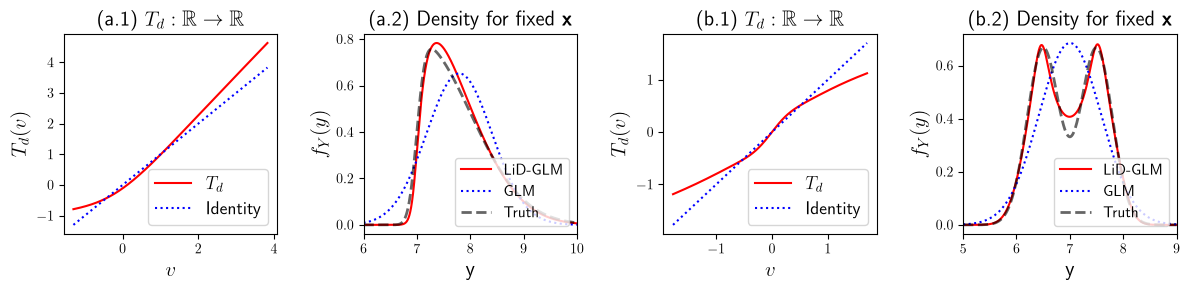

In [8]:
# we now plot the transformations $T_d$ as well as the resulting density in both cases

skewed_extended_glm.to("cpu")
skewed_extended_glm.eval()
multimodal_extended_glm.to("cpu")
multimodal_extended_glm.eval()
skewed_target_tensor = skewed_target_tensor.to("cpu")
skewed_covariate_tensor = skewed_covariate_tensor.to("cpu")
multimodal_target_tensor = multimodal_target_tensor.to("cpu")
multimodal_covariate_tensor = multimodal_covariate_tensor.to("cpu")
fig, axs = plt.subplots(1, 4, figsize=(12,3))
eval_util = Extended_glm_eval_utils()

#first, the transformations:
eval_util.plot_nu_2(extended_glm=skewed_extended_glm, exog=skewed_covariate_tensor, endog=skewed_target_tensor, ax = axs[0], label="$T_d$", legend = True, plot_identity=True)
eval_util.plot_nu_2(extended_glm=multimodal_extended_glm, exog=multimodal_covariate_tensor, endog=multimodal_target_tensor, ax = axs[2], label="$T_d$", legend = True, plot_identity=True)


# now the densities:
n_plot_points = 10**5
x= torch.ones(n_plot_points,1)
true_mean = function(x).reshape(-1)[0]
y_plot = torch.linspace(5,10,n_plot_points)

multimodal_density_plot = (norm.pdf(y_plot.detach().numpy(), loc = loc_1+true_mean, scale= scale_1)*0.5 
                + norm.pdf(y_plot.detach().numpy(), loc = loc_2+true_mean, scale=scale_2)*0.5)

#first, the skewed example:
skewed_temporary_mu = skewed_extended_glm.predict(torch.tensor(skewed_covariate_tensor, dtype = torch.float32)).reshape(-1)
skewed_temporary_mu_transf = skewed_extended_glm.predict_endog(torch.tensor(skewed_covariate_tensor, dtype = torch.float32)).reshape(-1)
skewed_temporary_backtransf_residual = skewed_extended_glm.net_transform_endog.inverse((torch.tensor(skewed_target_tensor, dtype = torch.float32)-skewed_temporary_mu_transf).reshape(-1,1))[0].reshape(-1)

skewed_density = torch.exp(skewed_extended_glm.log_like_obs(endog= y_plot, exog = x, dispersion = skewed_extended_glm.glm.family.dispersion(
                            endog=skewed_temporary_backtransf_residual + skewed_temporary_mu,
                            mu=skewed_temporary_mu))).detach()
untransf_density = torch.exp(skewed_extended_glm.log_like_untransformed(endog= y_plot, exog = x, dispersion = skewed_extended_glm.glm.family.dispersion(
                            endog=torch.tensor(skewed_target_tensor, dtype = torch.float32),
                            mu=skewed_temporary_mu)).detach())

axs[1].plot(y_plot.detach().numpy(), skewed_density.numpy(), c="red", label="LiD-GLM")
axs[1].plot(y_plot.detach().numpy(), skewed_traditional_results.get_distribution(sm.add_constant(x.detach().numpy(), prepend =False, has_constant='add')).pdf(y_plot.detach().numpy()),
             label= "GLM", c="blue", linestyle = ":")

axs[1].set_xlim(6, 10)
axs[1].plot(y_plot,skewnorm.pdf(y_plot-function(1), skew), lw=2, alpha=0.6, label='Truth', c="black", linestyle = "--")

axs[1].set_xlabel("y", fontsize = 15)
axs[1].set_title("(a.2) Density for fixed $\\textbf{x}$", fontsize = 15)
axs[1].set_ylabel("$f_Y(y)$", fontsize = 15)
axs[1].legend(fontsize = 11, loc = "lower right")

#now, the multimodal example:
multimodal_temporary_mu = multimodal_extended_glm.predict(torch.tensor(multimodal_covariate_tensor, dtype = torch.float32)).reshape(-1)
multimodal_temporary_mu_transf = multimodal_extended_glm.predict_endog(torch.tensor(multimodal_covariate_tensor, dtype = torch.float32)).reshape(-1)
multimodal_temporary_backtransf_residual = multimodal_extended_glm.net_transform_endog.inverse((torch.tensor(multimodal_target_tensor, dtype = torch.float32)-multimodal_temporary_mu_transf).reshape(-1,1))[0].reshape(-1)

multimodal_density = torch.exp(multimodal_extended_glm.log_like_obs(endog= y_plot, exog = x, dispersion = multimodal_extended_glm.glm.family.dispersion(
                            endog=multimodal_temporary_backtransf_residual + multimodal_temporary_mu,
                            mu=multimodal_temporary_mu))).detach()
axs[3].plot(y_plot.detach().numpy(), multimodal_density.numpy(), c="red", label="LiD-GLM")
axs[3].plot(y_plot.detach().numpy(), multimodal_traditional_results.get_distribution(sm.add_constant(x.detach().numpy(), prepend =False, has_constant='add')).pdf(y_plot.detach().numpy()), label= "GLM", c="blue", linestyle = ":")
axs[3].plot(y_plot.detach().numpy(), multimodal_density_plot, label= "Truth", c="black", linestyle = "--", lw=2, alpha=0.6)
axs[3].set_xlim(5, 9)
axs[3].legend(fontsize = 11, loc = "lower right")
axs[3].set_xlabel("y", fontsize = 15)
axs[3].set_ylabel("$f_Y(y)$", fontsize = 15)
axs[3].set_title("(b.2) Density for fixed $\\textbf{x}$", fontsize = 15)

axs[0].set_title(r"(a.1) $T_d: \mathbb{R}\to\mathbb{R}$", fontsize = 15)
axs[2].set_title(r"(b.1) $T_d:\mathbb{R}\to\mathbb{R}$", fontsize = 15)
fig.tight_layout()
#fig.savefig("T_d_examples_skewed_multimodal.pdf")